In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
import jax
import jax.numpy as jnp
from darnax.modules.conv.conv import Conv2D, Conv2DRecurrentDiscrete
from darnax.modules.conv.pooling import GlobalUnpooling, GlobalMajorityPooling
from darnax.modules.fully_connected import FullyConnected, FrozenRescaledFullyConnected
from darnax.modules.recurrent import RecurrentDiscrete
from darnax.modules.input_output import OutputLayer

In [4]:
from darnax.layer_maps.sparse import LayerMap
from darnax.states.sequential import SequentialState
from darnax.orchestrators.sequential import SequentialOrchestrator

In [5]:
import equinox as eqx
import jax.tree_util as jtu
import optax

## Importing the dataset (CIFAR)

In [6]:
from darnax.datasets.classification.cifar10 import Cifar10

data = Cifar10(
    batch_size=32,
    linear_projection=None,
    label_mode="pm1",
    x_transform="identity",
)

key = jax.random.PRNGKey(0)
key, data_key = jax.random.split(key)

data.build(key=data_key)

Array([2566685366, 2716172981], dtype=uint32)

In [7]:
# In order to do something:
# first we take a batch of data and we standardize it

x, y = next(iter(data))
print(f"Data shape: x={x.shape}, y={y.shape}")
print(f"Expected: x=(batch, 32, 32, 3), got x={x.shape}")

# If flattened, reshape it back
if x.ndim == 2:
    x = x.reshape(x.shape[0], 32, 32, 3)
    print(f"Reshaped x to: {x.shape}")

x = (x - x.mean()) / x.std()

Data shape: x=(32, 3072), y=(32, 10)
Expected: x=(batch, 32, 32, 3), got x=(32, 3072)
Reshaped x to: (32, 32, 32, 3)


## Build model 

In [ ]:
def build_conv_model(
    seed: int,
    in_channels: int = 3,
    spatial_size: int = 32,
    n_channels: int = 64,
    num_labels: int = 10,
    input_kernel_size: int = 7,
    recur_kernel_size: int = 7,
    threshold_conv: float = 1.7,
    threshold_fc: float = 1.7,
    threshold_out: float = 1.7,
    threshold_back: float = 0.0,
    j_d_conv: float = 0.9,
    j_d_fc: float = 0.9,
    strength_in: float = 1.0,
    strength_pool: float = 1.0,
    strength_unpool: float = 1.0,
    strength_wout: float = 1.0,
    strength_wback: float = 1.0,
    lr_conv: float = 1.0,
    weight_decay_conv: float = 0.0,
) -> tuple[SequentialState, SequentialOrchestrator]:

    keys = jax.random.split(jax.random.key(seed), 5)

    S = spatial_size

    layer_map = LayerMap.from_dict({
        1: {
            0: Conv2D(
                in_channels=in_channels,
                out_channels=n_channels,
                kernel_size=input_kernel_size,
                threshold=threshold_conv,
                strength=strength_in,
                key=keys[0],
                padding_mode="constant",
            ),
            1: Conv2DRecurrentDiscrete(
                channels=n_channels,
                kernel_size=recur_kernel_size,
                groups=n_channels,
                j_d=j_d_conv,
                threshold=threshold_conv,
                padding_mode="constant",
                key=keys[1],
                lr=lr_conv,
                weight_decay=weight_decay_conv,
            ),
            2: GlobalUnpooling(strength=strength_unpool, axis=(1, 2)),
        },
        2: {
            1: GlobalMajorityPooling(strength=strength_pool, axis=(1, 2)),
            2: RecurrentDiscrete(
                features=n_channels,
                j_d=j_d_fc,
                threshold=threshold_fc,
                key=keys[2],
            ),
            3: FrozenRescaledFullyConnected(
                in_features=num_labels,
                out_features=n_channels,
                strength=strength_wback,
                threshold=threshold_back,
                key=keys[3],
            ),
        },
        3: {
            2: FullyConnected(
                in_features=n_channels,
                out_features=num_labels,
                strength=strength_wout,
                threshold=threshold_out,
                key=keys[4],
            ),
            3: OutputLayer(),
        },
    })

    state = SequentialState([
        (S, S, in_channels),
        (S, S, n_channels),
        (n_channels,),
        (num_labels,),
    ])
    orchestrator = SequentialOrchestrator(layers=layer_map)

    return state, orchestrator

In [9]:
state_template, orchestrator = build_conv_model(seed=0)

## Initialize with x and y

In [10]:
state0 = state_template.init(x, y)

## Run dynamics 

In [11]:
N_WARMUP  = 1
N_CLAMPED = 5
N_FREE    = 5

def run_momentum(orch, state, rng, tau=0.0, n_warmup=N_WARMUP,
                 n_clamped=N_CLAMPED, n_free=N_FREE):
    """
    Dynamics with field-level momentum.

    Professor's formula:
        f(t+1) = tau * f(t)  +  (1 - tau) * h(t+1)
        s(t+1) = sign(f(t+1))

    where h(t+1) = reduce(messages(s(t))) is the raw local field,
    and s(t) = sign(f(t)) is the binarized state.

    tau = 0.0  →  f(t+1) = h(t+1)  →  identical to standard dynamics
    tau = 0.5  →  exponential moving average with half-life ~1 step
    tau = 0.9  →  very slow field, ~10 steps to "forget" the initial field

    Parameters
    ----------
    orch  : SequentialOrchestrator
    state : SequentialState   (initialized with state_template.init(x, y))
    rng   : JAX PRNGKey
    tau   : float in [0, 1)   momentum coefficient

    Returns
    -------
    history : list of SequentialState  (binarized states, one per step)
    fields  : dict {layer_idx: f_array}  (final continuous fields, for inspection)
    """
    # ── Initialise the continuous field buffers ──
    # We iterate over all receiver rows except the last (output) to get
    # the exact same set of layers that step() would update.
    fields = {
        r_idx: jnp.zeros_like(state.states[r_idx])
        for r_idx, _ in orch.lmap.row_items(skip_last=True, subset="all")
    }

    def one_step(state, fields, rng, filter_messages):
        """One momentum step: messages → h → momentum → sign → new s."""
        for r_idx, senders in orch.lmap.row_items(skip_last=True, subset=filter_messages):
            rng, sub = jax.random.split(rng)

            # Step 1: compute messages from the current binarized state s(t)
            #   orch._compute_messages() calls module(state[sender_idx], rng=sub)
            #   for each sender — same as what step() does internally.
            messages = orch._compute_messages(senders, state, rng=sub)

            # Step 2: reduce to get the raw local field h(t+1)
            #   This is the sum (or custom aggregation) of all incoming messages.
            h = orch.lmap[r_idx, r_idx].reduce(messages)

            # Step 3: momentum blend  ← THE NEW PART
            f_new = tau * fields[r_idx] + (1.0 - tau) * h

            # Step 4: binarize from the blended field (not directly from h)
            s_new = orch.lmap[r_idx, r_idx].activation(f_new)

            # Update both the continuous field and the binarized state
            fields[r_idx] = f_new
            state = state.replace_val(r_idx, s_new)

        return state, fields, rng

    history = []

    for _ in range(n_warmup):
        state, fields, rng = one_step(state, fields, rng, "inference")
        history.append(state)

    for _ in range(n_clamped):
        state, fields, rng = one_step(state, fields, rng, "all")
        history.append(state)

    for _ in range(n_free):
        state, fields, rng = one_step(state, fields, rng, "inference")
        history.append(state)

    return history, fields


In [12]:
history1 = run_momentum(orchestrator, state0, rng=jax.random.PRNGKey(42))

## Weight update

In [27]:
def build_optimizer(
    orchestrator: SequentialOrchestrator,
    lr_w_in: float = 0.1,
    lr_j_conv: float = 0.05,
    lr_j_fc: float = 0.05,
    lr_w_out: float = 0.1,
    trainable_overrides: dict[tuple[int, int], str] | None = None,
) -> tuple[optax.GradientTransformation, optax.OptState]:

    if trainable_overrides is None:
        trainable_overrides = {
            (1, 0): "w_in",
            (1, 1): "j_conv",
            (2, 2): "j_fc",
            (3, 2): "w_out",
        }

    # Build label tree: every leaf starts as "default" (frozen, lr=0)
    params, _ = eqx.partition(orchestrator, eqx.is_inexact_array)
    labels = jtu.tree_map(lambda _: "default", params, is_leaf=eqx.is_array)

    def like(tree, value: str):
        return jtu.tree_map(lambda _: value, tree, is_leaf=eqx.is_array)

    for (i, j), label in trainable_overrides.items():
        labels = eqx.tree_at(
            lambda m, _i=i, _j=j: m.lmap[_i][_j],
            labels,
            replace=like(params.lmap[i][j], label),
        )

    # Map each label → its SGD optimizer
    lr_map = {
        "w_in":  lr_w_in,
        "j_conv": lr_j_conv,
        "j_fc":  lr_j_fc,
        "w_out": lr_w_out,
    }
    transforms = {"default": optax.sgd(learning_rate=0.0)}
    transforms.update({lbl: optax.sgd(learning_rate=lr) for lbl, lr in lr_map.items()})

    optimizer = optax.multi_transform(transforms, labels)
    opt_state = optimizer.init(eqx.filter(orchestrator, eqx.is_inexact_array))

    return optimizer, opt_state

In [28]:
optimizer, opt_state = build_optimizer(orchestrator)

In [29]:
def apply_update(
    orchestrator: SequentialOrchestrator,
    state: SequentialState,
    rng,
    optimizer: optax.GradientTransformation,
    opt_state: optax.OptState,
) -> tuple[SequentialOrchestrator, optax.OptState]:
    """Compute the backward (Hebbian) grads and apply one weight update.

    Parameters
    ----------
    orchestrator:
        Current model.
    state:
        The ``SequentialState`` **after** dynamics have converged
        (i.e. the output of ``run_dynamics``).
    rng:
        A JAX PRNG key.
    optimizer:
        The optax optimizer returned by ``build_optimizer``.
    opt_state:
        Current optimizer state.

    Returns
    -------
    new_orchestrator:
        Updated model with new weights.
    new_opt_state:
        Updated optimizer state.
    """
    # Step 1: backward pass → raw Hebbian grads
    grads = orchestrator.backward(state, rng=rng)

    # Step 2: optimizer scales grads by per-module learning rates
    grads_filtered = eqx.filter(grads, eqx.is_inexact_array)
    params_filtered = eqx.filter(orchestrator, eqx.is_inexact_array)
    updates, new_opt_state = optimizer.update(
        grads_filtered, opt_state, params=params_filtered
    )

    # Step 3: apply updates → new orchestrator
    new_orchestrator = eqx.apply_updates(orchestrator, updates)

    return new_orchestrator, new_opt_state

In [16]:
new_orchestrator, new_opt_state = apply_update(
    orchestrator, state_after_dyn1, rng=jax.random.PRNGKey(42),
    optimizer=optimizer, opt_state=opt_state,
)

## Second dynamic

In [31]:
# Re-init from the SAME (x, y) to compare fairly
state0_fresh = state_template.init(x, y)
history2 = run_masked(new_orchestrator, state0_fresh, rng=jax.random.PRNGKey(42))

## Analysis — Before vs After Weight Update

Phase layout (default): step 0 = warmup, steps 1–5 = clamped, steps 6–10 = free

In [32]:
# =====================================================================
# Helper functions — reusable analysis tools
# =====================================================================

def extract_layer(history, layer_idx):
    """Return array (n_steps, batch, *spatial) for a given layer."""
    return [np.array(h.states[layer_idx]) for h in history]


def flatten_layer(activations):
    """Flatten spatial dims → list of (batch, features) arrays."""
    return [a.reshape(a.shape[0], -1) for a in activations]


# --- Cosine similarity matrix ---

def compute_cosine_similarity_matrix(history, layer_idx=1, batch_idx=None):
    """Pairwise cosine similarity between states at all time-step pairs."""
    acts = flatten_layer(extract_layer(history, layer_idx))
    T = len(acts)
    mat = np.zeros((T, T))
    for i in range(T):
        for j in range(i, T):
            if batch_idx is not None:
                sim = cosine_similarity([acts[i][batch_idx]], [acts[j][batch_idx]])[0, 0]
            else:
                sims = [cosine_similarity([acts[i][b]], [acts[j][b]])[0, 0]
                        for b in range(acts[i].shape[0])]
                sim = np.nanmean(sims)
            mat[i, j] = mat[j, i] = sim
    return mat


# --- Neuron flips ---

def compute_neuron_flips(history, layer_idx=1, percentage=True):
    """Fraction (or count) of neurons that flip sign between consecutive steps."""
    acts = flatten_layer(extract_layer(history, layer_idx))
    T = len(acts)
    flips = np.zeros(T - 1)
    for t in range(T - 1):
        diff = (acts[t] != acts[t + 1]).astype(float)  # (batch, features)
        if percentage:
            flips[t] = diff.mean() * 100  # average over batch & features
        else:
            flips[t] = diff.mean(axis=1).sum()  # average per sample, sum over batch
    return flips


# --- Clamped-free distance ---

def clamped_free_distance(history, layer_idx, n_warmup=1, n_clamped=5):
    """Cosine distance between end-of-clamped and end-of-free activations.

    Returns scalar = 1 − mean_batch( cos_sim(clamped_end, free_end) ).
    """
    acts = flatten_layer(extract_layer(history, layer_idx))
    idx_clamped_end = n_warmup + n_clamped - 1
    idx_free_end = len(acts) - 1
    sims = [cosine_similarity([acts[idx_clamped_end][b]], [acts[idx_free_end][b]])[0, 0]
            for b in range(acts[idx_clamped_end].shape[0])]
    return 1.0 - np.nanmean(sims)


# --- W_back overlap ---

def compute_wback_overlap(history, wback_module, layer_idx=2, output_idx=3):
    """Cosine similarity between wback(y) and layer_idx activation at each step."""
    T = len(history)
    overlaps = np.zeros(T)
    for t in range(T):
        output = np.array(history[t].states[output_idx])     # (batch, 10)
        projected = np.array(wback_module(output))            # (batch, N_CH)
        layer_act = np.array(history[t].states[layer_idx])    # (batch, N_CH)
        sims = []
        for b in range(layer_act.shape[0]):
            p, l = projected[b], layer_act[b]
            norm = np.linalg.norm(p) * np.linalg.norm(l) + 1e-8
            sims.append(np.dot(p, l) / norm)
        overlaps[t] = np.mean(sims)
    return overlaps

### 1. Cosine Similarity Matrices — before vs after update

Side-by-side comparison for both the conv layer (layer 1) and the FC layer (layer 2).

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_58726/2569765732.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


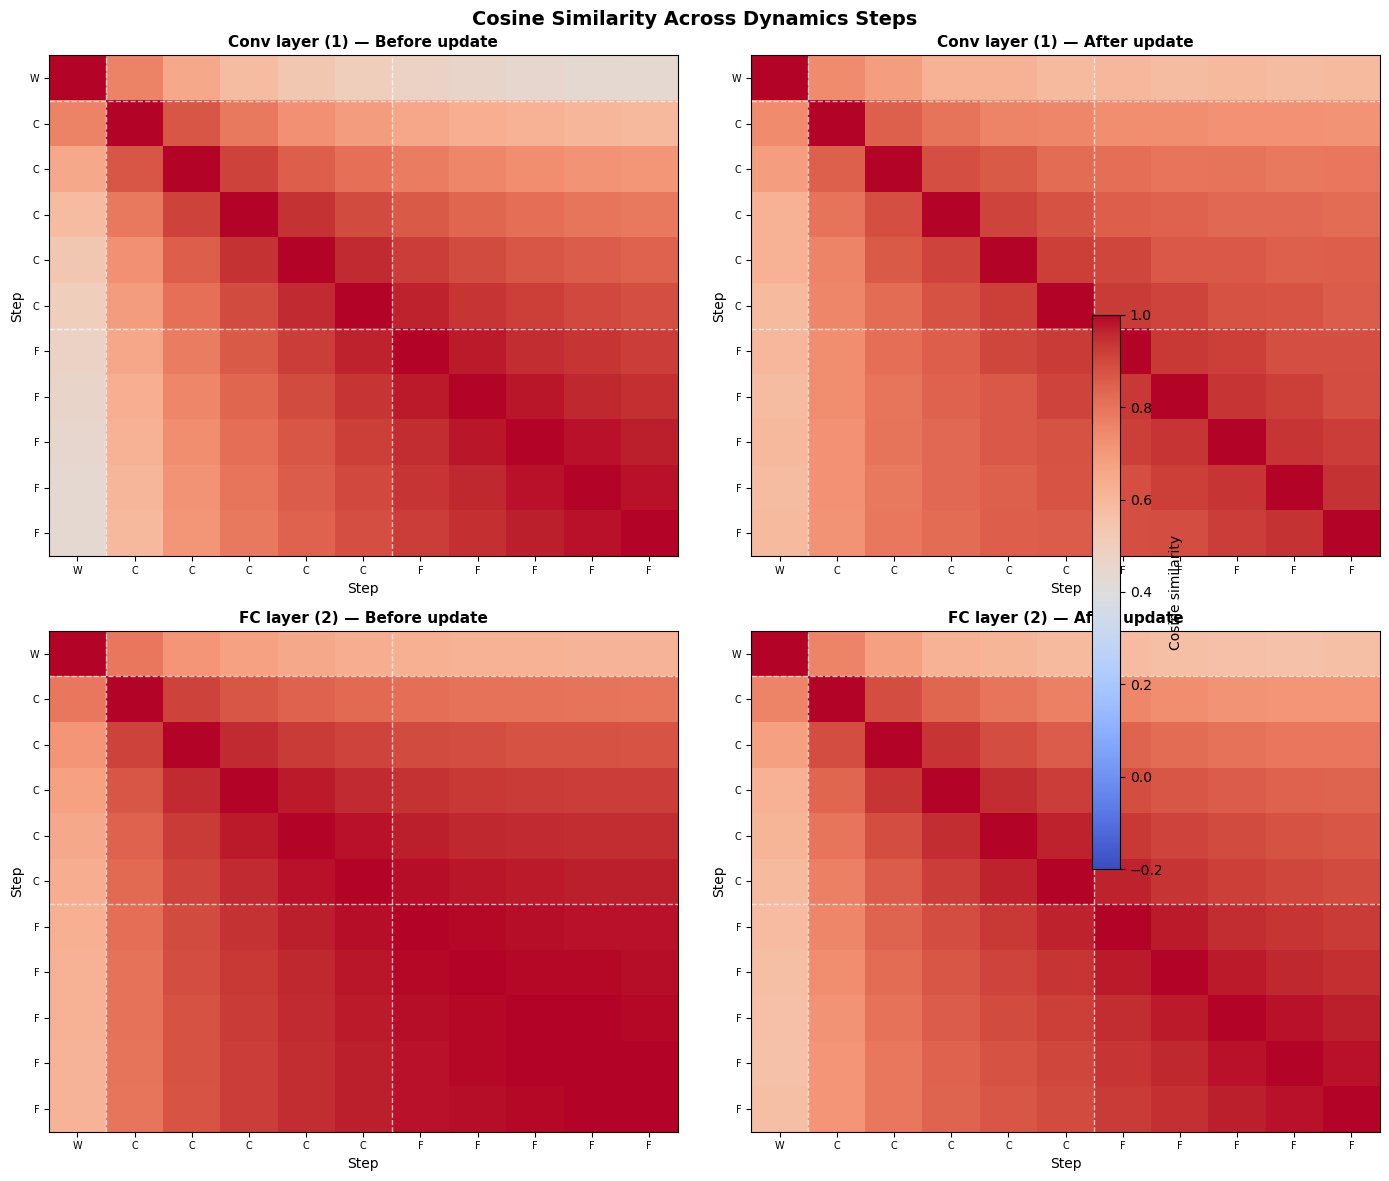

In [33]:
N_WARMUP, N_CLAMPED, N_FREE = 1, 5, 5
N_STEPS = N_WARMUP + N_CLAMPED + N_FREE
phase_labels = (["W"] * N_WARMUP + ["C"] * N_CLAMPED + ["F"] * N_FREE)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for col, (hist, title_tag) in enumerate([(history1, "Before update"), (history2, "After update")]):
    for row, (lidx, lname) in enumerate([(1, "Conv layer (1)"), (2, "FC layer (2)")]):
        ax = axes[row, col]
        cm = compute_cosine_similarity_matrix(hist, layer_idx=lidx)
        im = ax.imshow(cm, cmap="coolwarm", vmin=-0.2, vmax=1, aspect="auto")
        ax.set_title(f"{lname} — {title_tag}", fontsize=11, fontweight="bold")
        ax.set_xticks(range(N_STEPS))
        ax.set_xticklabels(phase_labels, fontsize=7)
        ax.set_yticks(range(N_STEPS))
        ax.set_yticklabels(phase_labels, fontsize=7)
        ax.set_xlabel("Step")
        ax.set_ylabel("Step")
        # Phase boundary lines
        for boundary in [N_WARMUP - 0.5, N_WARMUP + N_CLAMPED - 0.5]:
            ax.axhline(boundary, color="white", lw=1, ls="--", alpha=0.7)
            ax.axvline(boundary, color="white", lw=1, ls="--", alpha=0.7)

fig.colorbar(im, ax=axes, label="Cosine similarity", shrink=0.6)
fig.suptitle("Cosine Similarity Across Dynamics Steps", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2. Neuron Flips — before vs after update

Percentage of neurons that change sign between consecutive steps, for both layers.

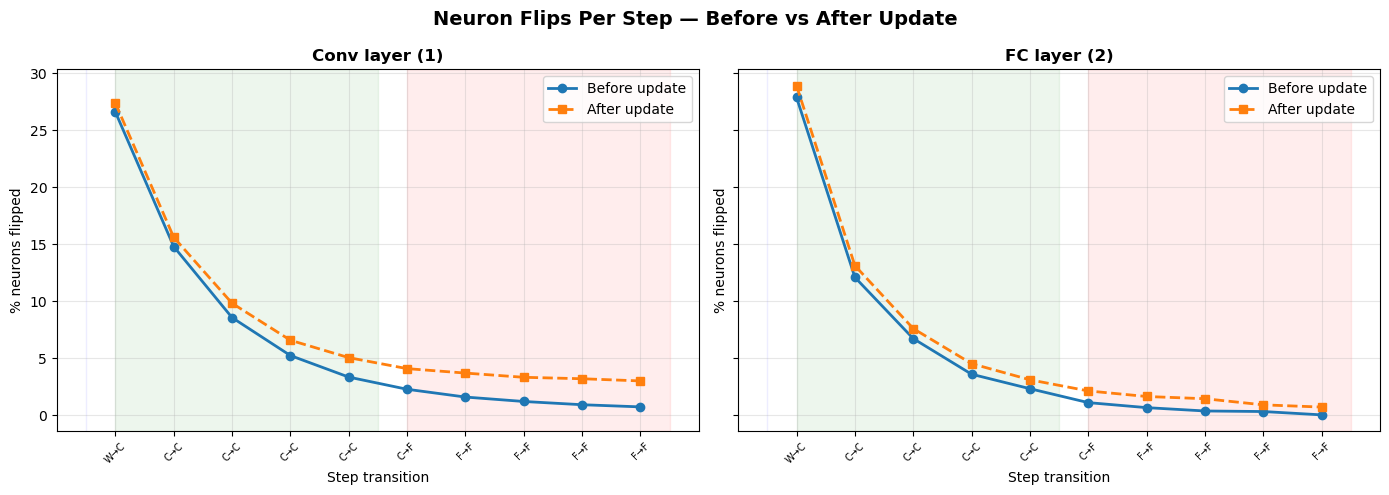

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
step_labels = phase_labels[1:]  # flips are between consecutive steps → N_STEPS-1

for ax, (lidx, lname) in zip(axes, [(1, "Conv layer (1)"), (2, "FC layer (2)")]):
    flips_before = compute_neuron_flips(history1, layer_idx=lidx, percentage=True)
    flips_after  = compute_neuron_flips(history2, layer_idx=lidx, percentage=True)

    xs = np.arange(len(flips_before))
    ax.plot(xs, flips_before, "o-", label="Before update", linewidth=2)
    ax.plot(xs, flips_after,  "s--", label="After update", linewidth=2)

    # Phase shading
    ax.axvspan(-0.5, N_WARMUP - 1.5, alpha=0.07, color="blue")
    ax.axvspan(N_WARMUP - 0.5 - 0.5, N_WARMUP + N_CLAMPED - 1.5, alpha=0.07, color="green")
    ax.axvspan(N_WARMUP + N_CLAMPED - 0.5 - 0.5, len(flips_before) - 0.5, alpha=0.07, color="red")

    ax.set_xlabel("Step transition")
    ax.set_ylabel("% neurons flipped")
    ax.set_title(lname, fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(xs)
    ax.set_xticklabels([f"{phase_labels[t]}→{phase_labels[t+1]}" for t in range(len(flips_before))],
                       rotation=45, fontsize=7)

fig.suptitle("Neuron Flips Per Step — Before vs After Update", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3. Clamped–Free Distance — does the update improve stability?

Cosine distance between end-of-clamped and end-of-free states.  
A **smaller** distance means the network retains the clamped representation better after the output is released.

In [35]:
layer_names = {1: "Conv layer (1)", 2: "FC layer (2)"}
print("Clamped–Free cosine distance (1 − cos_sim):")
print(f"{'Layer':<20s}  {'Before':>10s}  {'After':>10s}  {'Change':>10s}")
print("-" * 55)

for lidx in [1, 2]:
    d_before = clamped_free_distance(history1, lidx, N_WARMUP, N_CLAMPED)
    d_after  = clamped_free_distance(history2, lidx, N_WARMUP, N_CLAMPED)
    delta = d_after - d_before
    print(f"{layer_names[lidx]:<20s}  {d_before:>10.4f}  {d_after:>10.4f}  {delta:>+10.4f}")

Clamped–Free cosine distance (1 − cos_sim):
Layer                     Before       After      Change
-------------------------------------------------------
Conv layer (1)            0.1135      0.1416     +0.0281
FC layer (2)              0.0308      0.1065     +0.0758


### 4. W_back(y) overlap with FC layer (layer 2)

How well does the FC layer align with the target signal `wback(y)` at each step?

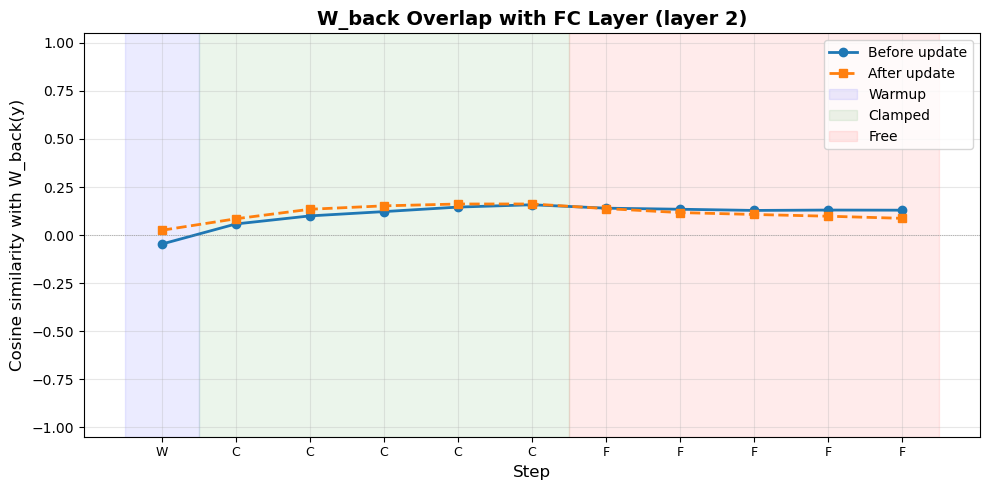

In [36]:
# Get the wback module from the orchestrator (same for both — it's frozen)
wback_module = orchestrator.lmap[2][3]

overlap_before = compute_wback_overlap(history1, wback_module, layer_idx=2, output_idx=3)
overlap_after  = compute_wback_overlap(history2, wback_module, layer_idx=2, output_idx=3)

fig, ax = plt.subplots(figsize=(10, 5))
xs = np.arange(N_STEPS)
ax.plot(xs, overlap_before, "o-", label="Before update", linewidth=2)
ax.plot(xs, overlap_after,  "s--", label="After update", linewidth=2)

# Phase shading
ax.axvspan(-0.5, N_WARMUP - 0.5, alpha=0.08, color="blue", label="Warmup")
ax.axvspan(N_WARMUP - 0.5, N_WARMUP + N_CLAMPED - 0.5, alpha=0.08, color="green", label="Clamped")
ax.axvspan(N_WARMUP + N_CLAMPED - 0.5, N_STEPS - 0.5, alpha=0.08, color="red", label="Free")

ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Cosine similarity with W_back(y)", fontsize=12)
ax.set_title("W_back Overlap with FC Layer (layer 2)", fontsize=14, fontweight="bold")
ax.set_xticks(xs)
ax.set_xticklabels(phase_labels, fontsize=9)
ax.set_ylim(-1.05, 1.05)
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Convergence trajectory — cosine similarity with final clamped state

For each step, how similar is the activation to the "goal" (end-of-clamped)?  
This shows whether the free phase drifts away — and whether the update reduces drift.

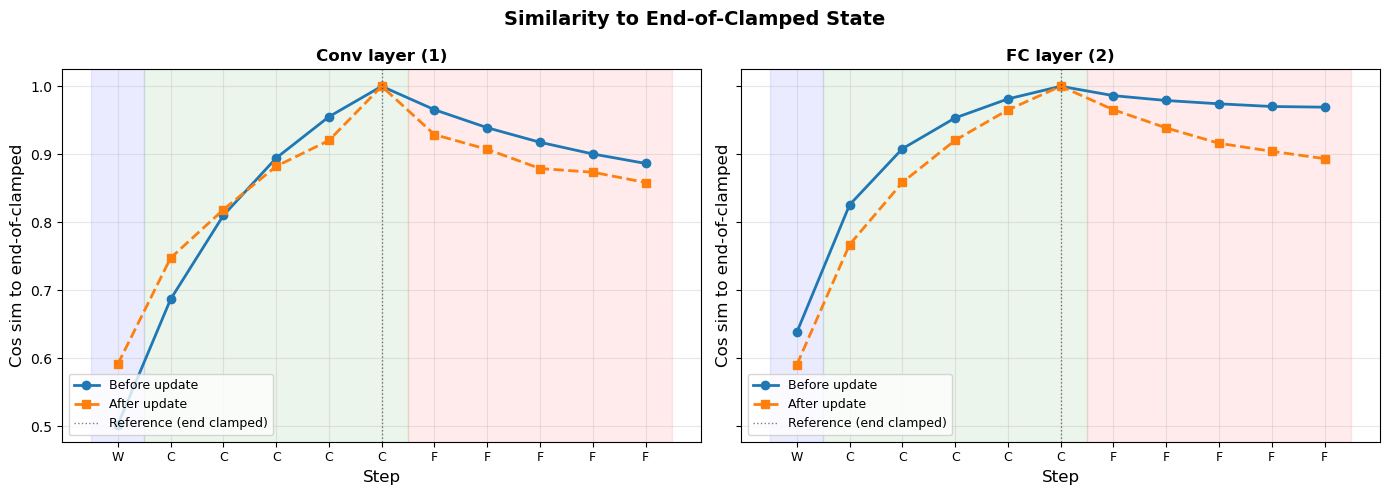

In [37]:
def sim_to_reference(history, layer_idx, ref_step_idx):
    """Cosine similarity of each step's activation to a reference step."""
    acts = flatten_layer(extract_layer(history, layer_idx))
    ref = acts[ref_step_idx]
    sims = []
    for t in range(len(acts)):
        batch_sims = [cosine_similarity([acts[t][b]], [ref[b]])[0, 0]
                      for b in range(ref.shape[0])]
        sims.append(np.nanmean(batch_sims))
    return np.array(sims)

ref_idx = N_WARMUP + N_CLAMPED - 1  # last clamped step

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (lidx, lname) in zip(axes, [(1, "Conv layer (1)"), (2, "FC layer (2)")]):
    sim_before = sim_to_reference(history1, lidx, ref_idx)
    sim_after  = sim_to_reference(history2, lidx, ref_idx)

    xs = np.arange(N_STEPS)
    ax.plot(xs, sim_before, "o-", label="Before update", linewidth=2)
    ax.plot(xs, sim_after,  "s--", label="After update", linewidth=2)

    ax.axvspan(-0.5, N_WARMUP - 0.5, alpha=0.08, color="blue")
    ax.axvspan(N_WARMUP - 0.5, N_WARMUP + N_CLAMPED - 0.5, alpha=0.08, color="green")
    ax.axvspan(N_WARMUP + N_CLAMPED - 0.5, N_STEPS - 0.5, alpha=0.08, color="red")

    ax.axvline(ref_idx, color="black", lw=1, ls=":", alpha=0.5, label="Reference (end clamped)")
    ax.set_xlabel("Step", fontsize=12)
    ax.set_ylabel("Cos sim to end-of-clamped", fontsize=12)
    ax.set_title(lname, fontsize=12, fontweight="bold")
    ax.set_xticks(xs)
    ax.set_xticklabels(phase_labels, fontsize=9)
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Similarity to End-of-Clamped State", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2. Weight change magnitude

How much did each trainable module's weights change after the update?

In [40]:
import jax.numpy as jnp

module_labels = {
    (1, 0): "W_in (Conv2D)",
    (1, 1): "J_conv (RecurrentConv)",
    (2, 2): "J_fc (RecurrentDiscrete)",
    (3, 2): "W_out (FullyConnected)",
}

print("Weight change after one update:")
print(f"{'Module':<30s}  {'‖ΔW‖':>10s}  {'‖W_old‖':>10s}  {'Rel. change':>12s}")
print("-" * 68)

for (i, j), label in module_labels.items():
    w_old = eqx.filter(orchestrator.lmap[i][j], eqx.is_inexact_array)
    w_new = eqx.filter(new_orchestrator.lmap[i][j], eqx.is_inexact_array)

    # Flatten all parameter leaves into one vector for each
    old_flat = jnp.concatenate([l.ravel() for l in jax.tree.leaves(w_old)])
    new_flat = jnp.concatenate([l.ravel() for l in jax.tree.leaves(w_new)])

    delta_norm = float(jnp.linalg.norm(new_flat - old_flat))
    old_norm = float(jnp.linalg.norm(old_flat))
    rel = delta_norm / (old_norm + 1e-8)

    print(f"{label:<30s}  {delta_norm:>10.4f}  {old_norm:>10.4f}  {rel:>11.4f}%")

Weight change after one update:
Module                                ‖ΔW‖     ‖W_old‖   Rel. change
--------------------------------------------------------------------
W_in (Conv2D)                     131.7177      8.2329      15.9989%
J_conv (RecurrentConv)             59.9497     56.4802       1.0614%
J_fc (RecurrentDiscrete)            0.4553     66.2311       0.0069%
W_out (FullyConnected)              0.3061      7.0399       0.0435%


## Multi-update experiment

Run 10 consecutive update steps (dynamics → backward → weight update) on the **same batch**.  
After each update, record key metrics to track how the network evolves.

In [41]:
N_UPDATES = 10

# Fresh model
state_template_m, orch_m = build_conv_model(seed=0)
optimizer_m, opt_state_m = build_optimizer(orch_m)
wback_m = orch_m.lmap[2][3]  # frozen, same across updates

# Storage for metrics at each update step
metrics = {
    "update":             [],       # 0 = before any update
    # Per-layer neuron flips (mean % across all dynamics steps)
    "flips_conv_mean":    [],
    "flips_fc_mean":      [],
    # Clamped-free distance
    "cf_dist_conv":       [],
    "cf_dist_fc":         [],
    "cf_dist_out":        [],
    # W_back overlap at end of free phase
    "wback_overlap_free": [],
    # Accuracy at end of free phase
    "acc_free":           [],
    # Weight norms
    "norm_j_conv":        [],
    "norm_j_fc":          [],
    "norm_w_out":         [],
    "norm_w_in":          [],
    # Full histories (for later plots)
    "histories":          [],
}

rng = jax.random.PRNGKey(42)

for step in range(N_UPDATES + 1):
    # --- Run dynamics ---
    s0 = state_template_m.init(x, y)
    rng, dyn_rng = jax.random.split(rng)
    hist = run_masked(orch_m, s0, rng=dyn_rng)

    # --- Record metrics ---
    metrics["update"].append(step)
    metrics["histories"].append(hist)

    flips_c = compute_neuron_flips(hist, layer_idx=1, percentage=True)
    flips_f = compute_neuron_flips(hist, layer_idx=2, percentage=True)
    metrics["flips_conv_mean"].append(flips_c.mean())
    metrics["flips_fc_mean"].append(flips_f.mean())

    metrics["cf_dist_conv"].append(clamped_free_distance(hist, 1, N_WARMUP, N_CLAMPED))
    metrics["cf_dist_fc"].append(clamped_free_distance(hist, 2, N_WARMUP, N_CLAMPED))
    metrics["cf_dist_out"].append(clamped_free_distance(hist, 3, N_WARMUP, N_CLAMPED))

    overlap = compute_wback_overlap(hist, wback_m, layer_idx=2, output_idx=3)
    metrics["wback_overlap_free"].append(overlap[-1])  # last free step

    # Weight norms
    for (i, j), key_name in {(1,0): "norm_w_in", (1,1): "norm_j_conv",
                              (2,2): "norm_j_fc", (3,2): "norm_w_out"}.items():
        w = eqx.filter(orch_m.lmap[i][j], eqx.is_inexact_array)
        flat = jnp.concatenate([l.ravel() for l in jax.tree.leaves(w)])
        metrics[key_name].append(float(jnp.linalg.norm(flat)))

    print(f"Update {step:2d} | flips conv={flips_c.mean():.1f}% fc={flips_f.mean():.1f}% | "
          f"cf_dist conv={metrics['cf_dist_conv'][-1]:.4f} fc={metrics['cf_dist_fc'][-1]:.4f} | "
          f"‖J_conv‖={metrics['norm_j_conv'][-1]:.2f}")

    # --- Weight update (skip after last iteration) ---
    if step < N_UPDATES:
        rng, upd_rng = jax.random.split(rng)
        orch_m, opt_state_m = apply_update(orch_m, hist[-1], rng=upd_rng,
                                           optimizer=optimizer_m, opt_state=opt_state_m)

print(f"\nDone — {N_UPDATES} updates completed.")

Update  0 | flips conv=6.6% fc=5.4% | cf_dist conv=0.1158 fc=0.0271 | ‖J_conv‖=56.48
Update  1 | flips conv=6.7% fc=6.0% | cf_dist conv=0.0864 fc=0.0938 | ‖J_conv‖=68.55
Update  2 | flips conv=7.8% fc=6.0% | cf_dist conv=0.1316 fc=0.0865 | ‖J_conv‖=71.95
Update  3 | flips conv=9.1% fc=6.5% | cf_dist conv=0.1837 fc=0.1216 | ‖J_conv‖=78.58
Update  4 | flips conv=9.2% fc=6.3% | cf_dist conv=0.1786 fc=0.0993 | ‖J_conv‖=89.78
Update  5 | flips conv=10.2% fc=6.5% | cf_dist conv=0.2189 fc=0.1041 | ‖J_conv‖=102.89
Update  6 | flips conv=11.5% fc=6.7% | cf_dist conv=0.2736 fc=0.1374 | ‖J_conv‖=118.45
Update  7 | flips conv=14.1% fc=7.2% | cf_dist conv=0.3584 fc=0.1598 | ‖J_conv‖=137.28
Update  8 | flips conv=13.7% fc=7.7% | cf_dist conv=0.3500 fc=0.2015 | ‖J_conv‖=166.22
Update  9 | flips conv=17.0% fc=8.3% | cf_dist conv=0.4667 fc=0.2416 | ‖J_conv‖=192.06
Update 10 | flips conv=17.6% fc=9.3% | cf_dist conv=0.4881 fc=0.3140 | ‖J_conv‖=227.44

Done — 10 updates completed.


## Multi-update experiment

Run 10 consecutive update steps (dynamics → backward → weight update) on the **same batch**.  
After each update, record key metrics to track how the network evolves.

In [ ]:
N_UPDATES = 10

# Fresh model
state_template_m, orch_m = build_conv_model(seed=0)
optimizer_m, opt_state_m = build_optimizer(orch_m)
wback_m = orch_m.lmap[2][3]  # frozen, same across updates

# Storage for metrics at each update step
metrics = {
    "update":             [],       # 0 = before any update
    # Per-layer neuron flips (mean % across all dynamics steps)
    "flips_conv_mean":    [],
    "flips_fc_mean":      [],
    # Clamped-free distance
    "cf_dist_conv":       [],
    "cf_dist_fc":         [],
    "cf_dist_out":        [],
    # W_back overlap at end of free phase
    "wback_overlap_free": [],
    # Accuracy at end of free phase
    "acc_free":           [],
    # Weight norms
    "norm_j_conv":        [],
    "norm_j_fc":          [],
    "norm_w_out":         [],
    "norm_w_in":          [],
    # Full histories (for later plots)
    "histories":          [],
}

rng = jax.random.PRNGKey(42)

for step in range(N_UPDATES + 1):
    # --- Run dynamics ---
    s0 = state_template_m.init(x, y)
    rng, dyn_rng = jax.random.split(rng)
    state_final, hist = run_dynamics(orch_m, s0, rng=dyn_rng)

    # --- Record metrics ---
    metrics["update"].append(step)
    metrics["histories"].append(hist)

    flips_c = compute_neuron_flips(hist, layer_idx=1, percentage=True)
    flips_f = compute_neuron_flips(hist, layer_idx=2, percentage=True)
    metrics["flips_conv_mean"].append(flips_c.mean())
    metrics["flips_fc_mean"].append(flips_f.mean())

    metrics["cf_dist_conv"].append(clamped_free_distance(hist, 1, N_WARMUP, N_CLAMPED))
    metrics["cf_dist_fc"].append(clamped_free_distance(hist, 2, N_WARMUP, N_CLAMPED))
    metrics["cf_dist_out"].append(clamped_free_distance(hist, 3, N_WARMUP, N_CLAMPED))

    overlap = compute_wback_overlap(hist, wback_m, layer_idx=2, output_idx=3)
    metrics["wback_overlap_free"].append(overlap[-1])  # last free step

    # Weight norms
    for (i, j), key_name in {(1,0): "norm_w_in", (1,1): "norm_j_conv",
                              (2,2): "norm_j_fc", (3,2): "norm_w_out"}.items():
        w = eqx.filter(orch_m.lmap[i][j], eqx.is_inexact_array)
        flat = jnp.concatenate([l.ravel() for l in jax.tree.leaves(w)])
        metrics[key_name].append(float(jnp.linalg.norm(flat)))

    print(f"Update {step:2d} | flips conv={flips_c.mean():.1f}% fc={flips_f.mean():.1f}% | "
          f"cf_dist conv={metrics['cf_dist_conv'][-1]:.4f} fc={metrics['cf_dist_fc'][-1]:.4f} | "
          f"‖J_conv‖={metrics['norm_j_conv'][-1]:.2f}")

    # --- Weight update (skip after last iteration) ---
    if step < N_UPDATES:
        rng, upd_rng = jax.random.split(rng)
        orch_m, opt_state_m = apply_update(orch_m, state_final, rng=upd_rng,
                                           optimizer=optimizer_m, opt_state=opt_state_m)

print(f"\nDone — {N_UPDATES} updates completed.")

Update  0 | flips conv=2.9% fc=0.9% | cf_dist conv=0.0632 fc=0.0176 | ‖J_conv‖=56.48
Update  1 | flips conv=23.9% fc=4.4% | cf_dist conv=0.4842 fc=0.1719 | ‖J_conv‖=83.23
Update  2 | flips conv=46.6% fc=9.5% | cf_dist conv=0.9436 fc=0.3027 | ‖J_conv‖=201.38
Update  3 | flips conv=60.8% fc=13.2% | cf_dist conv=1.2283 fc=0.4883 | ‖J_conv‖=411.15
Update  4 | flips conv=58.1% fc=15.1% | cf_dist conv=1.1709 fc=0.5537 | ‖J_conv‖=661.76
Update  5 | flips conv=70.8% fc=18.0% | cf_dist conv=1.4097 fc=0.6367 | ‖J_conv‖=910.32
Update  6 | flips conv=84.5% fc=20.2% | cf_dist conv=1.6841 fc=0.6699 | ‖J_conv‖=1204.64
Update  7 | flips conv=91.3% fc=22.2% | cf_dist conv=1.8175 fc=0.6875 | ‖J_conv‖=1548.11
Update  8 | flips conv=94.7% fc=22.8% | cf_dist conv=1.8800 fc=0.6885 | ‖J_conv‖=1918.58
Update  9 | flips conv=96.3% fc=24.0% | cf_dist conv=1.9114 fc=0.6953 | ‖J_conv‖=2303.72
Update 10 | flips conv=97.8% fc=23.5% | cf_dist conv=1.9362 fc=0.5605 | ‖J_conv‖=2695.71

Done — 10 updates completed.


### Multi-update: summary curves

Tracking key metrics across the 10 update steps.

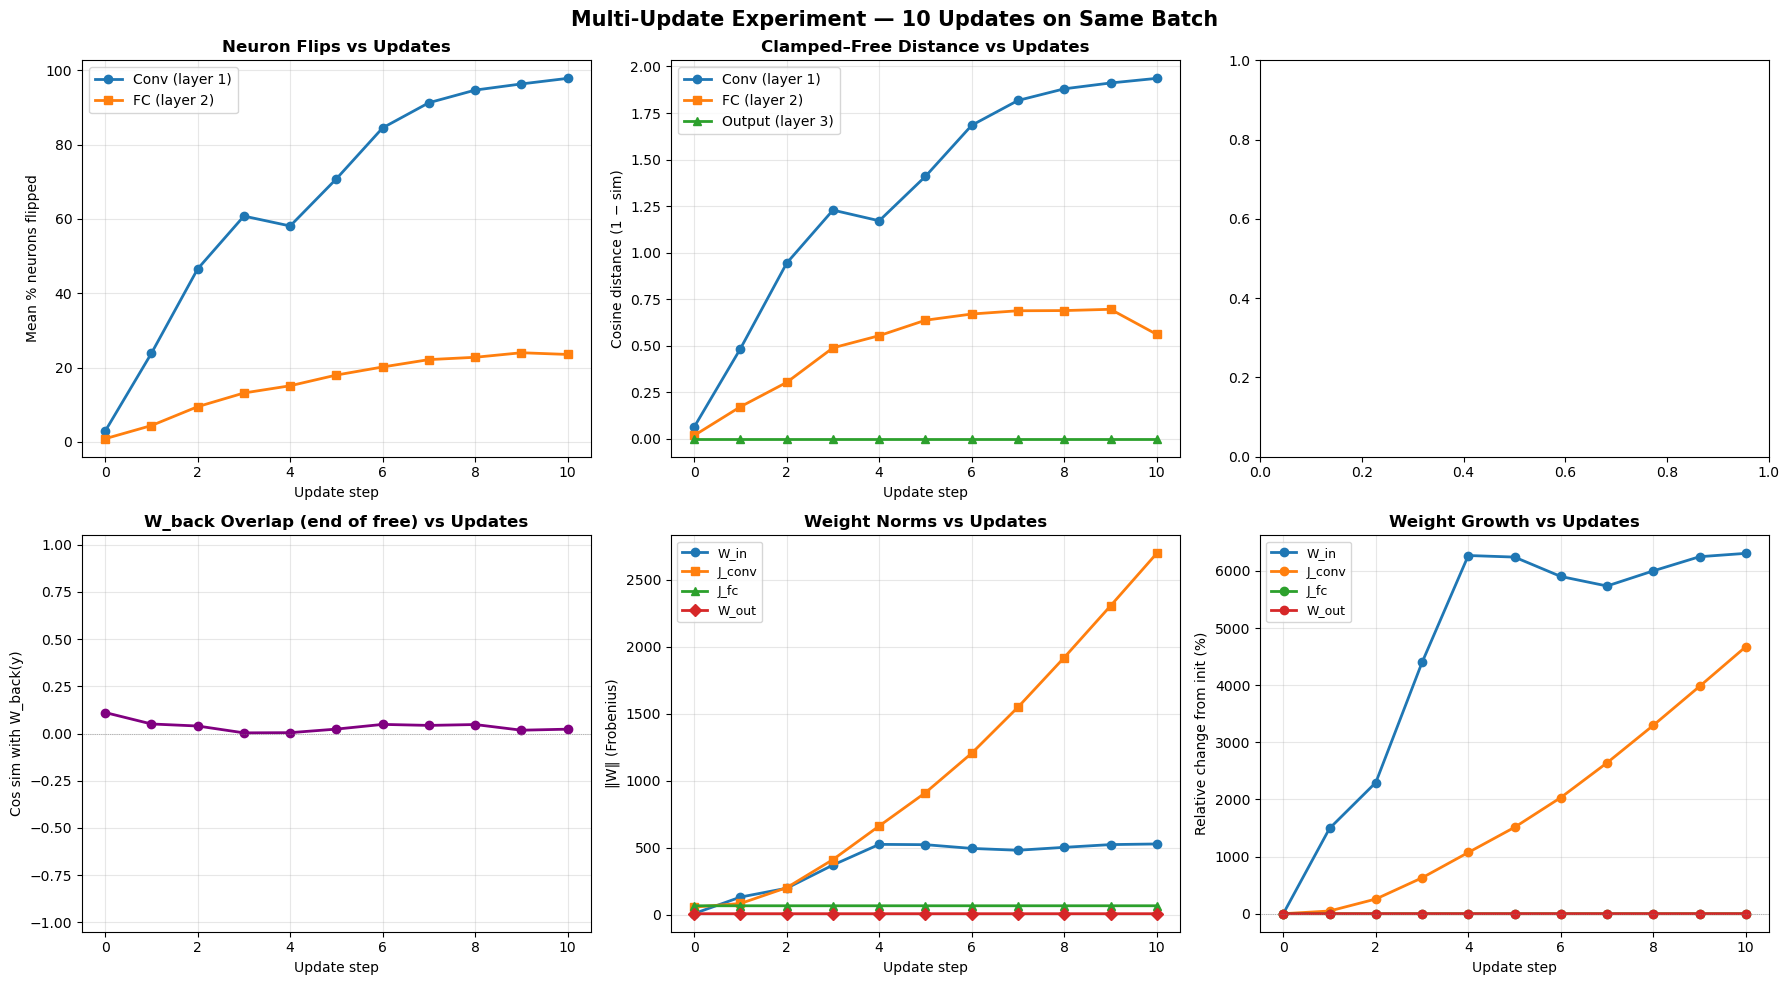

In [ ]:
ups = metrics["update"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Neuron flips
ax = axes[0, 0]
ax.plot(ups, metrics["flips_conv_mean"], "o-", label="Conv (layer 1)", linewidth=2)
ax.plot(ups, metrics["flips_fc_mean"], "s-", label="FC (layer 2)", linewidth=2)
ax.set_xlabel("Update step")
ax.set_ylabel("Mean % neurons flipped")
ax.set_title("Neuron Flips vs Updates", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Clamped-free distance
ax = axes[0, 1]
ax.plot(ups, metrics["cf_dist_conv"], "o-", label="Conv (layer 1)", linewidth=2)
ax.plot(ups, metrics["cf_dist_fc"], "s-", label="FC (layer 2)", linewidth=2)
ax.plot(ups, metrics["cf_dist_out"], "^-", label="Output (layer 3)", linewidth=2)
ax.set_xlabel("Update step")
ax.set_ylabel("Cosine distance (1 − sim)")
ax.set_title("Clamped–Free Distance vs Updates", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# 4. W_back overlap
ax = axes[1, 0]
ax.plot(ups, metrics["wback_overlap_free"], "o-", color="purple", linewidth=2)
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Update step")
ax.set_ylabel("Cos sim with W_back(y)")
ax.set_title("W_back Overlap (end of free) vs Updates", fontweight="bold")
ax.set_ylim(-1.05, 1.05)
ax.grid(True, alpha=0.3)

# 5. Weight norms
ax = axes[1, 1]
ax.plot(ups, metrics["norm_w_in"], "o-", label="W_in", linewidth=2)
ax.plot(ups, metrics["norm_j_conv"], "s-", label="J_conv", linewidth=2)
ax.plot(ups, metrics["norm_j_fc"], "^-", label="J_fc", linewidth=2)
ax.plot(ups, metrics["norm_w_out"], "D-", label="W_out", linewidth=2)
ax.set_xlabel("Update step")
ax.set_ylabel("‖W‖ (Frobenius)")
ax.set_title("Weight Norms vs Updates", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 6. Weight norm relative change from initial
ax = axes[1, 2]
for key, label in [("norm_w_in", "W_in"), ("norm_j_conv", "J_conv"),
                    ("norm_j_fc", "J_fc"), ("norm_w_out", "W_out")]:
    initial = metrics[key][0]
    rel_change = [(v - initial) / (initial + 1e-8) * 100 for v in metrics[key]]
    ax.plot(ups, rel_change, "o-", label=label, linewidth=2)
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Update step")
ax.set_ylabel("Relative change from init (%)")
ax.set_title("Weight Growth vs Updates", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle(f"Multi-Update Experiment — {N_UPDATES} Updates on Same Batch", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### Multi-update: cosine similarity evolution

Cosine similarity matrices at update steps 0, 1, 3, 5, 10 — to see the checkerboard developing.

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_25446/4272263041.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


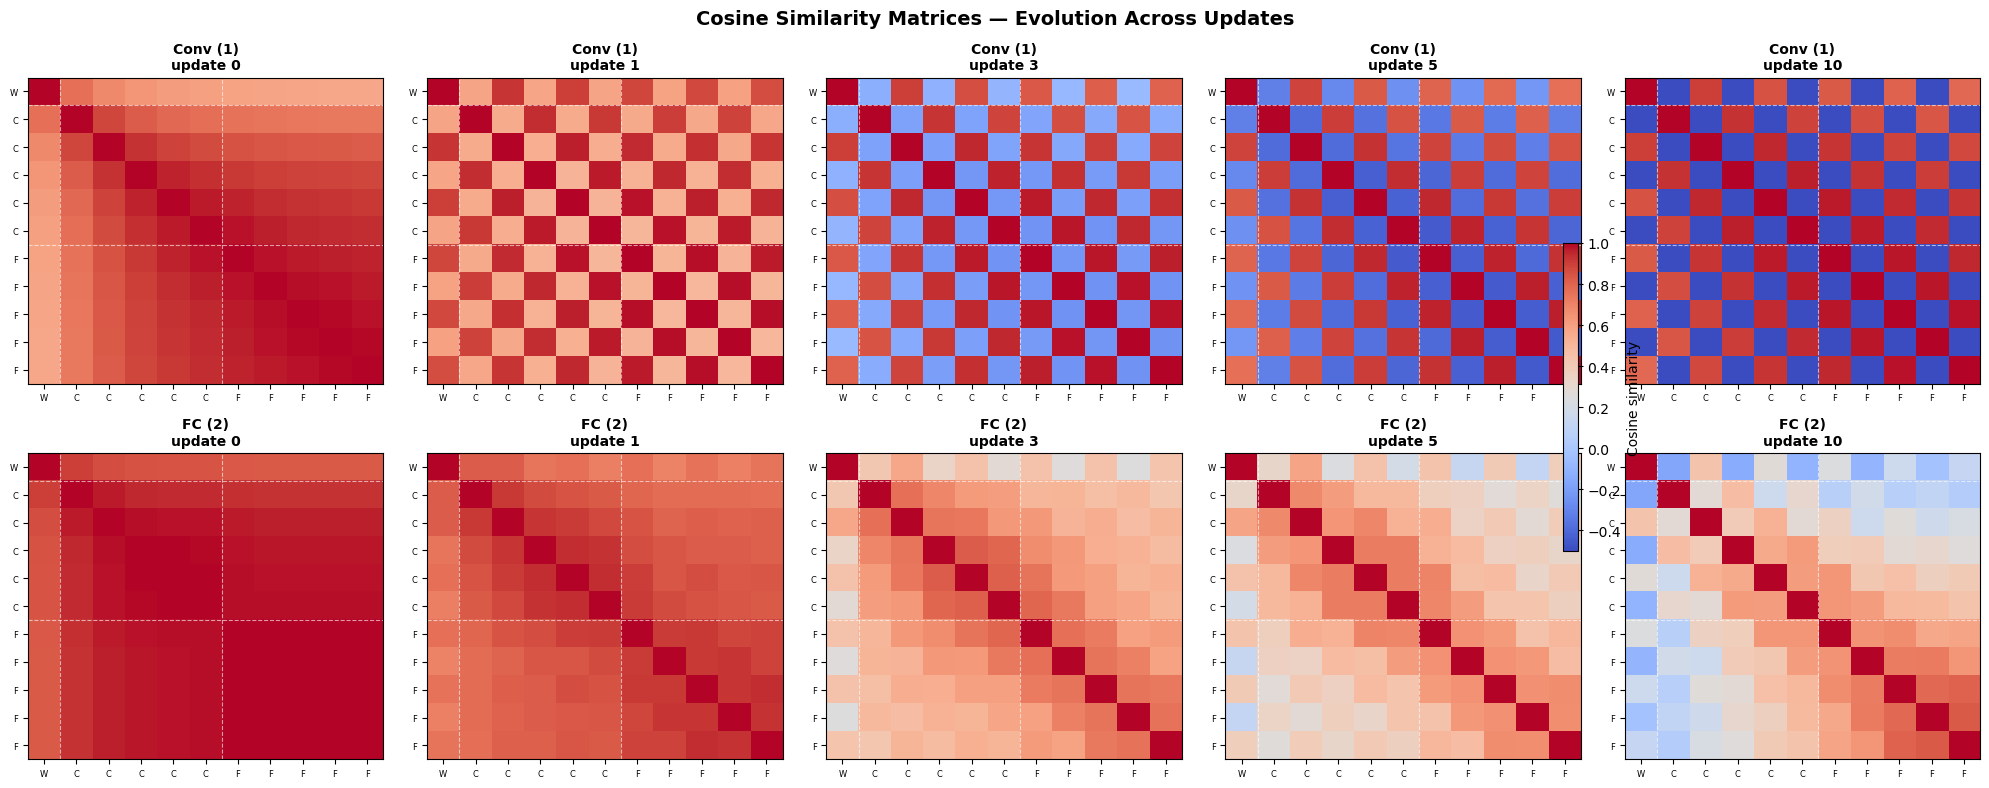

In [ ]:
snapshot_steps = [0, 1, 3, 5, 10]
snapshot_steps = [s for s in snapshot_steps if s <= N_UPDATES]

fig, axes = plt.subplots(2, len(snapshot_steps), figsize=(4 * len(snapshot_steps), 8))

for col, step_idx in enumerate(snapshot_steps):
    hist = metrics["histories"][step_idx]
    for row, (lidx, lname) in enumerate([(1, "Conv (1)"), (2, "FC (2)")]):
        ax = axes[row, col]
        cm = compute_cosine_similarity_matrix(hist, layer_idx=lidx)
        im = ax.imshow(cm, cmap="coolwarm", vmin=-0.5, vmax=1, aspect="auto")
        ax.set_title(f"{lname}\nupdate {step_idx}", fontsize=10, fontweight="bold")
        ax.set_xticks(range(N_STEPS))
        ax.set_xticklabels(phase_labels, fontsize=6)
        ax.set_yticks(range(N_STEPS))
        ax.set_yticklabels(phase_labels, fontsize=6)
        for boundary in [N_WARMUP - 0.5, N_WARMUP + N_CLAMPED - 0.5]:
            ax.axhline(boundary, color="white", lw=0.8, ls="--", alpha=0.6)
            ax.axvline(boundary, color="white", lw=0.8, ls="--", alpha=0.6)

fig.colorbar(im, ax=axes, label="Cosine similarity", shrink=0.5)
fig.suptitle("Cosine Similarity Matrices — Evolution Across Updates", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Multi-update: neuron flip profiles at selected updates

Full flip-per-step curves overlaid, to see how the per-step flipping pattern changes.

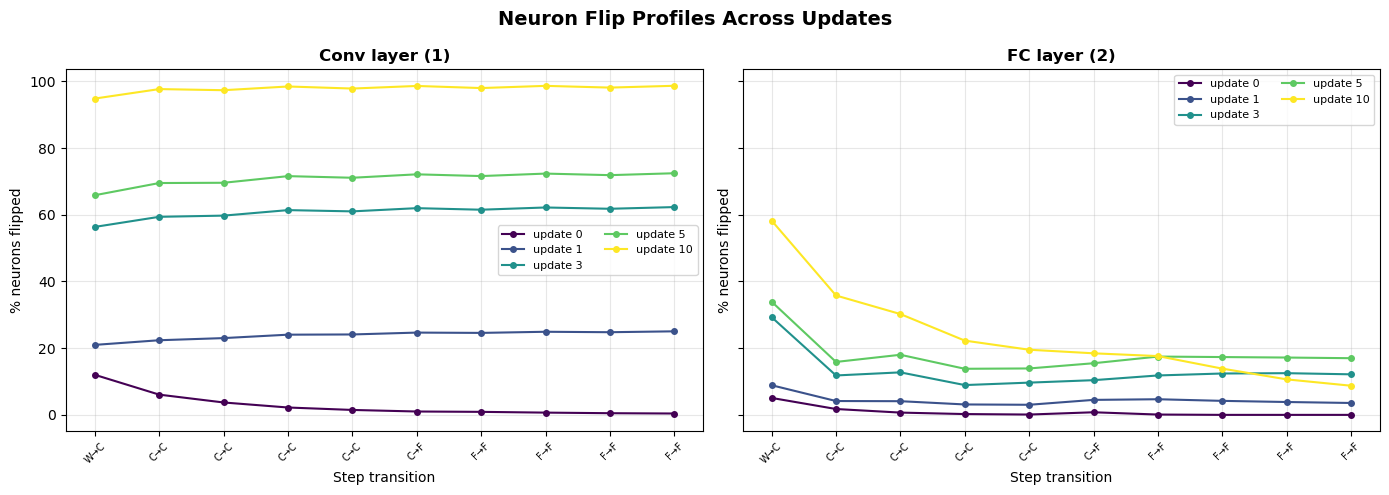

In [ ]:
from matplotlib.cm import viridis

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = viridis(np.linspace(0, 1, len(snapshot_steps)))

for ax, (lidx, lname) in zip(axes, [(1, "Conv layer (1)"), (2, "FC layer (2)")]):
    for color, step_idx in zip(colors, snapshot_steps):
        flips = compute_neuron_flips(metrics["histories"][step_idx], layer_idx=lidx, percentage=True)
        xs = np.arange(len(flips))
        ax.plot(xs, flips, "o-", color=color, label=f"update {step_idx}", linewidth=1.5, markersize=4)

    ax.set_xlabel("Step transition")
    ax.set_ylabel("% neurons flipped")
    ax.set_title(lname, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(xs)
    ax.set_xticklabels([f"{phase_labels[t]}→{phase_labels[t+1]}" for t in range(len(flips))],
                       rotation=45, fontsize=7)

fig.suptitle("Neuron Flip Profiles Across Updates", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Multi-update: summary curves

Tracking key metrics across the 10 update steps.

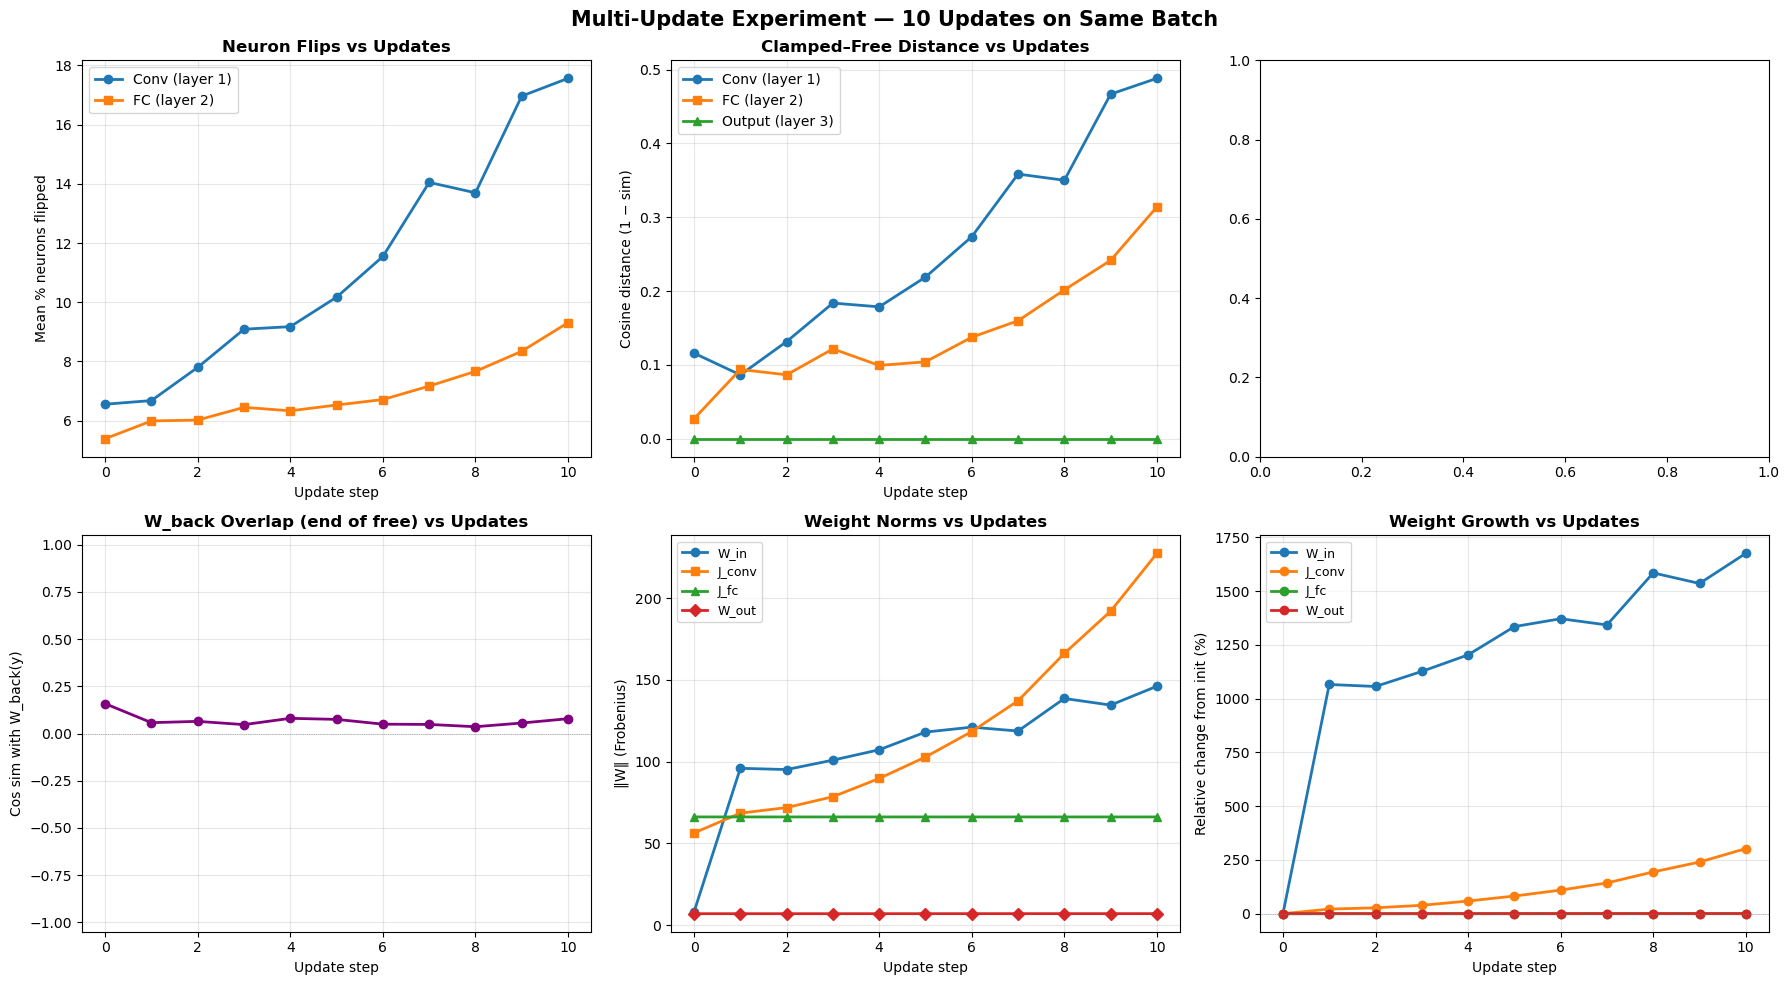

In [42]:
ups = metrics["update"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Neuron flips
ax = axes[0, 0]
ax.plot(ups, metrics["flips_conv_mean"], "o-", label="Conv (layer 1)", linewidth=2)
ax.plot(ups, metrics["flips_fc_mean"], "s-", label="FC (layer 2)", linewidth=2)
ax.set_xlabel("Update step")
ax.set_ylabel("Mean % neurons flipped")
ax.set_title("Neuron Flips vs Updates", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Clamped-free distance
ax = axes[0, 1]
ax.plot(ups, metrics["cf_dist_conv"], "o-", label="Conv (layer 1)", linewidth=2)
ax.plot(ups, metrics["cf_dist_fc"], "s-", label="FC (layer 2)", linewidth=2)
ax.plot(ups, metrics["cf_dist_out"], "^-", label="Output (layer 3)", linewidth=2)
ax.set_xlabel("Update step")
ax.set_ylabel("Cosine distance (1 − sim)")
ax.set_title("Clamped–Free Distance vs Updates", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# 4. W_back overlap
ax = axes[1, 0]
ax.plot(ups, metrics["wback_overlap_free"], "o-", color="purple", linewidth=2)
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Update step")
ax.set_ylabel("Cos sim with W_back(y)")
ax.set_title("W_back Overlap (end of free) vs Updates", fontweight="bold")
ax.set_ylim(-1.05, 1.05)
ax.grid(True, alpha=0.3)

# 5. Weight norms
ax = axes[1, 1]
ax.plot(ups, metrics["norm_w_in"], "o-", label="W_in", linewidth=2)
ax.plot(ups, metrics["norm_j_conv"], "s-", label="J_conv", linewidth=2)
ax.plot(ups, metrics["norm_j_fc"], "^-", label="J_fc", linewidth=2)
ax.plot(ups, metrics["norm_w_out"], "D-", label="W_out", linewidth=2)
ax.set_xlabel("Update step")
ax.set_ylabel("‖W‖ (Frobenius)")
ax.set_title("Weight Norms vs Updates", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 6. Weight norm relative change from initial
ax = axes[1, 2]
for key, label in [("norm_w_in", "W_in"), ("norm_j_conv", "J_conv"),
                    ("norm_j_fc", "J_fc"), ("norm_w_out", "W_out")]:
    initial = metrics[key][0]
    rel_change = [(v - initial) / (initial + 1e-8) * 100 for v in metrics[key]]
    ax.plot(ups, rel_change, "o-", label=label, linewidth=2)
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Update step")
ax.set_ylabel("Relative change from init (%)")
ax.set_title("Weight Growth vs Updates", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle(f"Multi-Update Experiment — {N_UPDATES} Updates on Same Batch", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### Multi-update: cosine similarity evolution

Cosine similarity matrices at update steps 0, 1, 3, 5, 10 — to see the checkerboard developing.

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_58726/4272263041.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


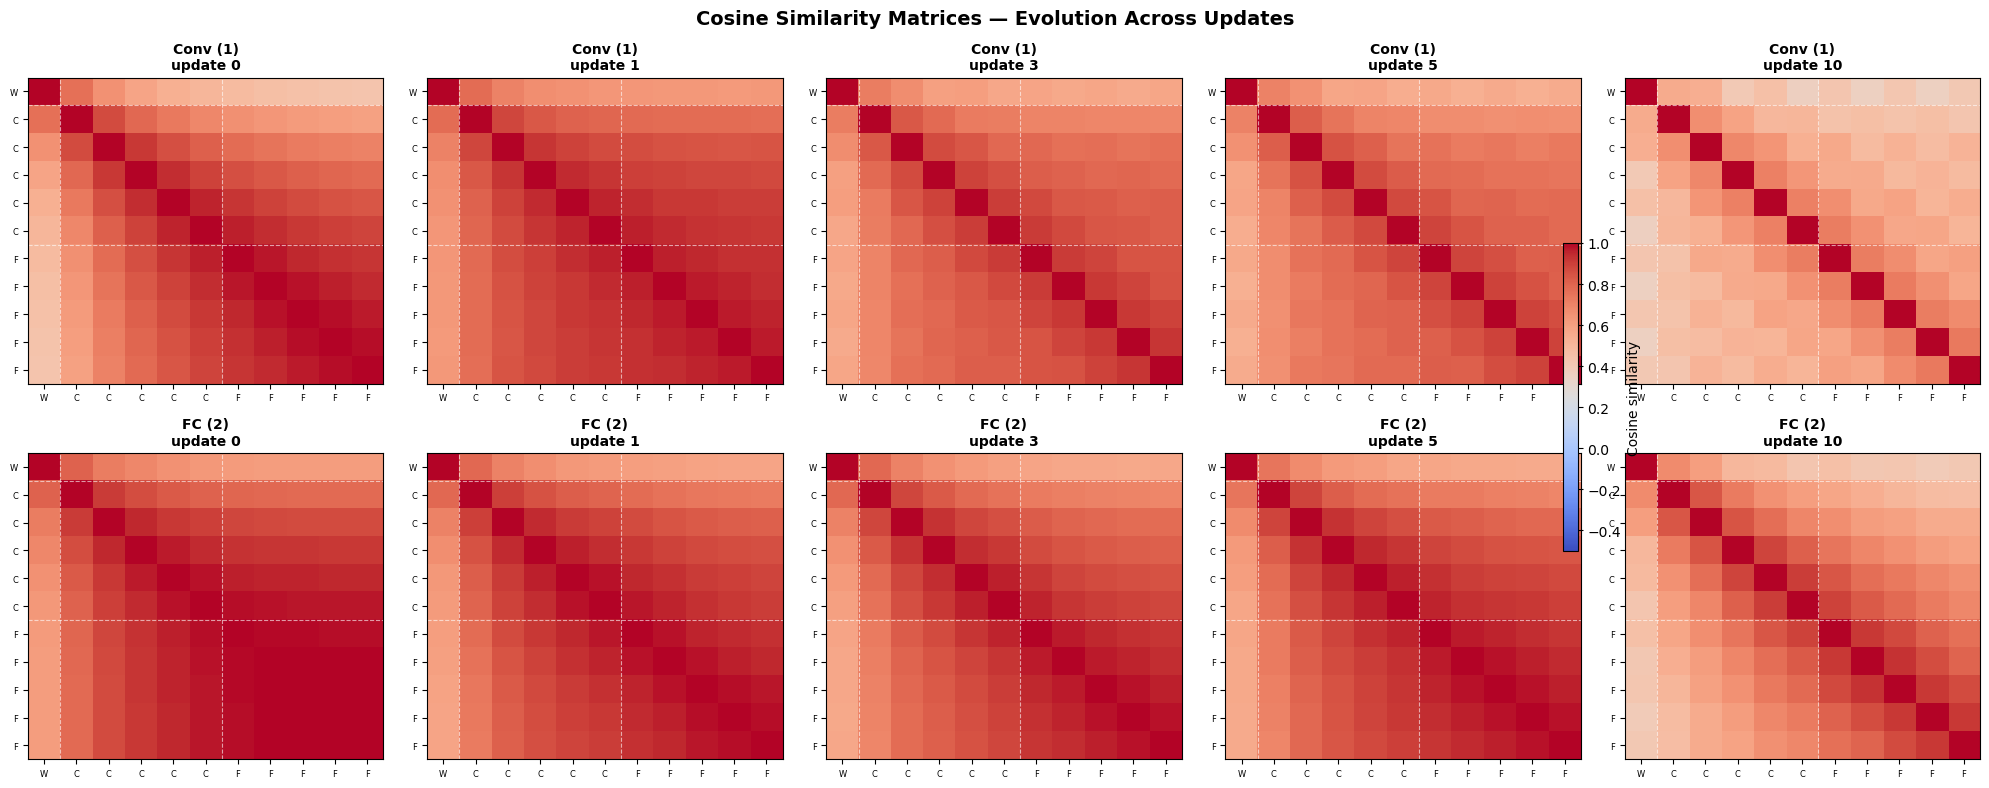

In [43]:
snapshot_steps = [0, 1, 3, 5, 10]
snapshot_steps = [s for s in snapshot_steps if s <= N_UPDATES]

fig, axes = plt.subplots(2, len(snapshot_steps), figsize=(4 * len(snapshot_steps), 8))

for col, step_idx in enumerate(snapshot_steps):
    hist = metrics["histories"][step_idx]
    for row, (lidx, lname) in enumerate([(1, "Conv (1)"), (2, "FC (2)")]):
        ax = axes[row, col]
        cm = compute_cosine_similarity_matrix(hist, layer_idx=lidx)
        im = ax.imshow(cm, cmap="coolwarm", vmin=-0.5, vmax=1, aspect="auto")
        ax.set_title(f"{lname}\nupdate {step_idx}", fontsize=10, fontweight="bold")
        ax.set_xticks(range(N_STEPS))
        ax.set_xticklabels(phase_labels, fontsize=6)
        ax.set_yticks(range(N_STEPS))
        ax.set_yticklabels(phase_labels, fontsize=6)
        for boundary in [N_WARMUP - 0.5, N_WARMUP + N_CLAMPED - 0.5]:
            ax.axhline(boundary, color="white", lw=0.8, ls="--", alpha=0.6)
            ax.axvline(boundary, color="white", lw=0.8, ls="--", alpha=0.6)

fig.colorbar(im, ax=axes, label="Cosine similarity", shrink=0.5)
fig.suptitle("Cosine Similarity Matrices — Evolution Across Updates", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Multi-update: neuron flip profiles at selected updates

Full flip-per-step curves overlaid, to see how the per-step flipping pattern changes.

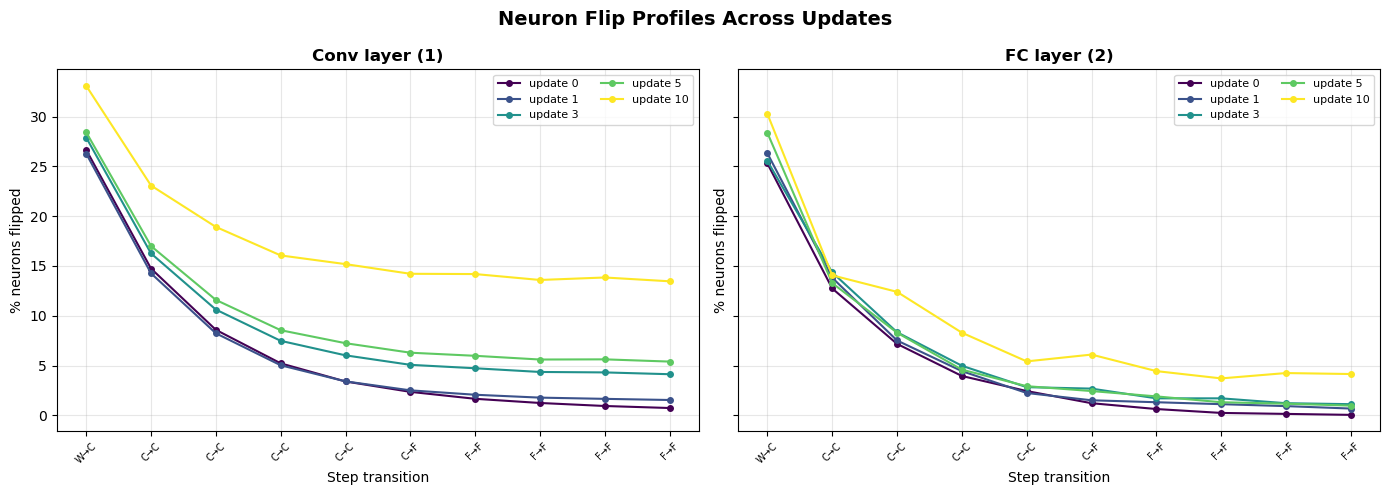

In [44]:
from matplotlib.cm import viridis

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = viridis(np.linspace(0, 1, len(snapshot_steps)))

for ax, (lidx, lname) in zip(axes, [(1, "Conv layer (1)"), (2, "FC layer (2)")]):
    for color, step_idx in zip(colors, snapshot_steps):
        flips = compute_neuron_flips(metrics["histories"][step_idx], layer_idx=lidx, percentage=True)
        xs = np.arange(len(flips))
        ax.plot(xs, flips, "o-", color=color, label=f"update {step_idx}", linewidth=1.5, markersize=4)

    ax.set_xlabel("Step transition")
    ax.set_ylabel("% neurons flipped")
    ax.set_title(lname, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(xs)
    ax.set_xticklabels([f"{phase_labels[t]}→{phase_labels[t+1]}" for t in range(len(flips))],
                       rotation=45, fontsize=7)

fig.suptitle("Neuron Flip Profiles Across Updates", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()